# Phase 3: Model Architecture Justification & Training

This notebook covers the following aspects of Milestone 2 and 3:
- Data-driven justification for the chosen modeling approach based on EDA.
- Implementing and validating the proposed model using the engineered features.
- Saving the trained model artifact for the backend API.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
import joblib

# Load the engineered dataset
df = pd.read_csv('../Engineered_Features.csv', parse_dates=['Datetime'], index_col='Datetime')
print(f"Dataset shape: {df.shape}")
display(df.head())


Dataset shape: (17472, 14)


,F1_132KV_PowerConsumption,F2_132KV_PowerConsumption,F3_132KV_PowerConsumption,Total_PowerConsumption,Temperature,Humidity,CloudCover,WindSpeed,Hour,Minute,DayOfWeek,Month,Is_Weekend,Is_Holiday
Datetime,,,,,,,,,,,,,,
2017-01-01 00:00:00,30999.493670,18170.212767,20013.493977,69183.200413,14.70,89.0,18.0,6.8,0,0,6,1,1,0
2017-01-01 00:30:00,27396.455697,17883.282673,18490.602410,63770.340780,14.55,90.5,20.5,6.6,0,30,6,1,1,0
2017-01-01 01:00:00,25407.594937,16627.355623,17476.626507,59511.577067,14.40,92.0,23.0,6.4,1,0,6,1,1,0
2017-01-01 01:30:00,23906.835443,15529.483283,16609.156627,56045.475353,14.30,93.0,23.0,6.0,1,30,6,1,1,0
2017-01-01 02:00:00,22474.936707,14767.173253,15870.843373,53112.953333,14.20,94.0,23.0,5.6,2,0,6,1,1,0


## 3.1 Model Architecture Justification

Based on the Exploratory Data Analysis, the power demand exhibits:
1. **Strong non-linear patterns**: Daily cycles (peak/off-peak hours) and seasonal weather impacts.
2. **Categorical influences**: Weekends and specific local holidays (e.g., Chhath Puja, Durga Puja) cause sharp deviations from normal patterns.
3. **Weather correlation**: Temperature and humidity have complex, non-linear relationships with power demand (e.g., high demand during both very cold and very hot periods).

**Chosen Model: Random Forest Regressor**
- **Why**: Random Forests excel at capturing complex, non-linear interactions without requiring extensive scaling or normalization of features. They naturally handle categorical-like integer features (Hour, DayOfWeek, Month) and are highly robust to outliers that might still exist in the data. They also provide feature importance out-of-the-box.
- **Alternative considered**: ARIMA/SARIMA are excellent for linear time series but struggle with external regressors like specific localized holidays and complex weather interactions without manual feature engineering. Deep Learning (LSTMs) requires significantly more data and tuning.


In [2]:
# Prepare Features (X) and Target (y)
# We want to predict Total_PowerConsumption. 
# We'll drop individual feeder consumption as they sum up to our target.
features = ['Temperature', 'Humidity', 'CloudCover', 'WindSpeed', 
            'Hour', 'Minute', 'DayOfWeek', 'Month', 'Is_Weekend', 'Is_Holiday']
target = 'Total_PowerConsumption'

X = df[features]
y = df[target]

# Drop any remaining NaNs
X = X.dropna()
y = y.loc[X.index]

# Time-based train-test split (Last 30 days for testing)
split_idx = int(len(X) * 0.9)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Testing set: {X_test.shape[0]} samples")


Training set: 15723 samples
Testing set: 1748 samples


## 3.2 Model Training and Validation
We'll train the Random Forest Regressor and evaluate it on the holdout test set using MAE and RMSE.


In [3]:
# Initialize and train the model
rf_model = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# Predictions
y_pred = rf_model.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")


Mean Absolute Error (MAE): 6028.95
Root Mean Squared Error (RMSE): 8468.39
Mean Absolute Percentage Error (MAPE): 9.03%


## 3.3 Visualizing Predictions vs Actuals
Let's visualize how our model performs on a 3-day slice of the test set.


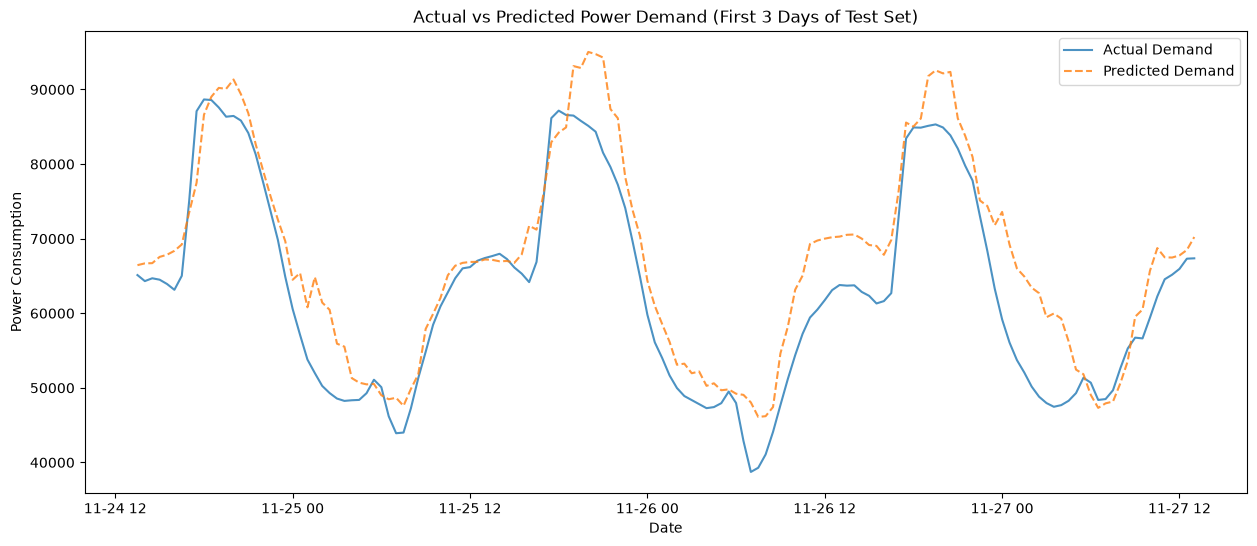

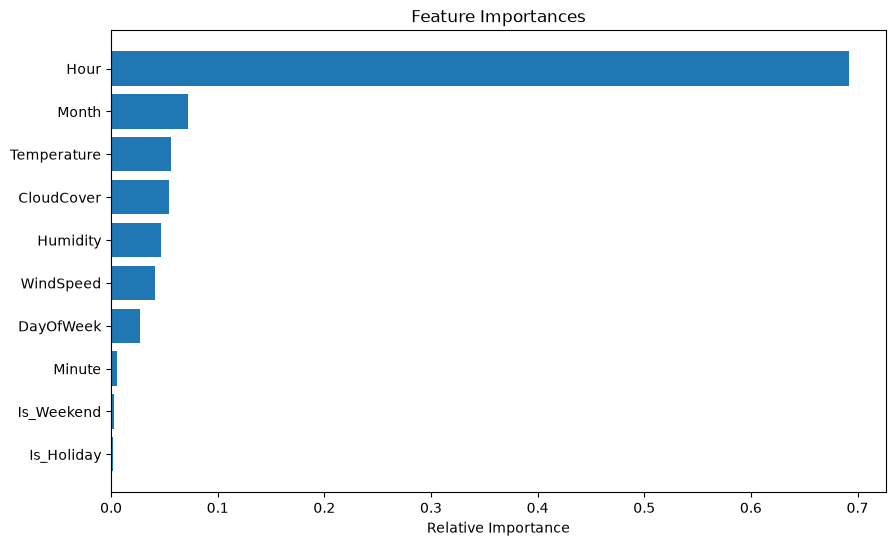

In [4]:
plt.figure(figsize=(15, 6))
# Plot first 144 blocks (3 days * 48 blocks)
plot_slice = 144
plt.plot(y_test.index[:plot_slice], y_test.values[:plot_slice], label='Actual Demand', alpha=0.8)
plt.plot(y_test.index[:plot_slice], y_pred[:plot_slice], label='Predicted Demand', alpha=0.8, linestyle='--')
plt.title('Actual vs Predicted Power Demand (First 3 Days of Test Set)')
plt.ylabel('Power Consumption')
plt.xlabel('Date')
plt.legend()
plt.show()

# Feature Importance
importances = rf_model.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(10, 6))
plt.title('Feature Importances')
plt.barh(range(len(indices)), importances[indices], align='center')
plt.yticks(range(len(indices)), [features[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()


## 3.4 Saving the Model Artifact
We will export the trained model to a `.pkl` file so that the FastAPI backend can load it and serve predictions.


In [5]:
# Save the model
model_path = '../model.pkl'
joblib.dump(rf_model, model_path)
print(f"Model successfully saved to {model_path}")


Model successfully saved to ../model.pkl
